In [71]:
# Video Game Sales Analysis Project
# Comprehensive EDA, SQL Analysis, Visualizations, and ML Models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay)

print("All libraries imported successfully!")

All libraries imported successfully!


In [72]:
# 1. DATA LOADING
# Load the dataset
df = pd.read_csv('vgsales.csv.zip')
print("Dataset loaded!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

# Define sales columns early - used in EDA
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# Basic info
print("\nDataset Info:")
print(df.info())

print("\nDescriptive Statistics:")
display(df.describe())

Dataset loaded!
Shape: (16598, 11)

First 5 rows:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None

Descriptive Statistics:


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [73]:
# 2. DATA CLEANING & PREPROCESSING

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# Check for missing values
missing = df.isnull().sum()
print("\nMissing Values:")
print(missing[missing > 0])

# First, we mark which rows had missing Year values before any imputation
df['Year_was_missing'] = df['Year'].isnull()
n_missing_year = df['Year_was_missing'].sum()
print(f"\nRows with missing Year: {n_missing_year} ({n_missing_year/len(df)*100:.2f}%)")

df['Publisher'] = df['Publisher'].fillna('Unknown')

# For ML features, imputing Year with median is still acceptable.
# The model will also receive the 'Year_was_missing' flag and can learn
# that these values are "unknown".
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Year'] = df['Year'].astype(int)

# However, for TIME-BASED analysis (yearly trends, "year with highest sales", etc.)
# we create a separate dataframe WITHOUT artificially filled years
# to avoid distorting the temporal distribution.
df_time = df[~df['Year_was_missing']].copy()
print(f"Rows available for time-based analysis: {len(df_time)} (excluded {n_missing_year} with unknown year)")

Number of duplicate rows: 0

Missing Values:
Year         271
Publisher     58
dtype: int64

Rows with missing Year: 271 (1.63%)
Rows available for time-based analysis: 16327 (excluded 271 with unknown year)


In [74]:
# 3. EXTENDED SQL ANALYSIS

# Create SQLite database
conn = sqlite3.connect('vgsales.db')
df.to_sql('games', conn, if_exists='replace', index=False)
df_time.to_sql('games_time', conn, if_exists='replace', index=False)
print("SQL Database created successfully.\n")

sql_queries = {
    "1. Top 15 Games by Global Sales": """
        SELECT Rank, Name, Platform, Year, Genre, Publisher, Global_Sales
        FROM games
        ORDER BY Global_Sales DESC
        LIMIT 15
    """,

    "2. Sales by Genre (detailed)": """
        SELECT Genre,
               ROUND(SUM(Global_Sales), 2) as Total_Global_Sales,
               COUNT(*) as Total_Games,
               ROUND(AVG(Global_Sales), 2) as Avg_Sales_Per_Game,
               ROUND(SUM(NA_Sales), 2) as NA_Total,
               ROUND(SUM(EU_Sales), 2) as EU_Total,
               ROUND(SUM(JP_Sales), 2) as JP_Total
        FROM games
        GROUP BY Genre
        ORDER BY Total_Global_Sales DESC
    """,

    "3. Top 10 Publishers by Revenue": """
        SELECT Publisher,
               ROUND(SUM(Global_Sales), 2) as Total_Sales,
               COUNT(*) as Games_Published,
               ROUND(AVG(Global_Sales), 2) as Avg_Sales_Per_Game
        FROM games
        GROUP BY Publisher
        ORDER BY Total_Sales DESC
        LIMIT 10
    """,

    "4. Sales Trend by Year": """
            SELECT Year,
                  ROUND(SUM(Global_Sales), 2) as Total_Sales,
                  COUNT(*) as Games_Released
            FROM games_time
            GROUP BY Year
            ORDER BY Year DESC
        """,

    "5. Best Platform per Genre": """
        SELECT Genre, Platform, Total_Sales, Game_Count
        FROM (
            SELECT Genre, Platform,
                   ROUND(SUM(Global_Sales), 2) as Total_Sales,
                   COUNT(*) as Game_Count,
                   RANK() OVER (PARTITION BY Genre ORDER BY SUM(Global_Sales) DESC) as rank
            FROM games
            GROUP BY Genre, Platform
        )
        WHERE rank = 1
        ORDER BY Total_Sales DESC
    """,

    "6. Regional Market Share (%)": """
        SELECT
            ROUND(100.0 * SUM(NA_Sales) / SUM(Global_Sales), 2) as NA_Share,
            ROUND(100.0 * SUM(EU_Sales) / SUM(Global_Sales), 2) as EU_Share,
            ROUND(100.0 * SUM(JP_Sales) / SUM(Global_Sales), 2) as JP_Share,
            ROUND(100.0 * SUM(Other_Sales) / SUM(Global_Sales), 2) as Other_Share
        FROM games
    """,

    "7. Nintendo vs Others": """
        SELECT
            CASE WHEN Publisher LIKE '%Nintendo%' THEN 'Nintendo' ELSE 'Others' END as Publisher_Group,
            ROUND(SUM(Global_Sales), 2) as Total_Sales,
            COUNT(*) as Games
        FROM games
        GROUP BY Publisher_Group
    """,

    "8. Top 3 Games per Platform": """
        SELECT Platform, Name, Global_Sales, Year
        FROM (
            SELECT Platform, Name, Global_Sales, Year,
                   RANK() OVER (PARTITION BY Platform ORDER BY Global_Sales DESC) as rank
            FROM games
        )
        WHERE rank <= 3
        ORDER BY Platform, rank
    """,

    "9. Games Released After 2010 with High Sales": """
        SELECT Name, Platform, Genre, Publisher, Global_Sales, Year
        FROM games
        WHERE Year > 2010 AND Global_Sales > 5
        ORDER BY Global_Sales DESC
    """,

    "10. Average Sales by Platform (Top 10, min 20 games)": """
        SELECT Platform,
              ROUND(AVG(Global_Sales), 3) as Avg_Global_Sales,
              COUNT(*) as Total_Games,
              ROUND(SUM(Global_Sales), 2) as Total_Sales
        FROM games
        GROUP BY Platform
        HAVING COUNT(*) >= 20
        ORDER BY Avg_Global_Sales DESC
        LIMIT 10
    """,

        "11. Most Popular Genre per Year": """
            SELECT Year, Genre, Total_Sales
            FROM (
                SELECT Year, Genre, SUM(Global_Sales) as Total_Sales,
                      RANK() OVER (PARTITION BY Year ORDER BY SUM(Global_Sales) DESC) as rank
                FROM games_time
                GROUP BY Year, Genre
            )
            WHERE rank = 1
            ORDER BY Year DESC
        """,

    "12. Publishers with Most Games": """
        SELECT Publisher, COUNT(*) as Games_Count, ROUND(SUM(Global_Sales), 2) as Total_Sales
        FROM games
        GROUP BY Publisher
        ORDER BY Games_Count DESC
        LIMIT 10
    """,

    "13. Sales Distribution by Platform Family": """
        SELECT
            CASE
                WHEN Platform IN ('PS','PS2','PS3','PS4','PSP','PSV') THEN 'PlayStation'
                WHEN Platform IN ('XB','X360','XOne') THEN 'Xbox'
                WHEN Platform IN ('NES','SNES','N64','GC','Wii','WiiU','GB','GBA','DS','3DS') THEN 'Nintendo'
                WHEN Platform = 'PC' THEN 'PC'
                ELSE 'Other'
            END as Platform_Family,
            ROUND(SUM(Global_Sales), 2) as Total_Sales,
            COUNT(*) as Games
        FROM games
        GROUP BY Platform_Family
        ORDER BY Total_Sales DESC
    """,

    "14. Top Action Games": """
        SELECT Name, Platform, Year, Global_Sales
        FROM games
        WHERE Genre = 'Action'
        ORDER BY Global_Sales DESC
        LIMIT 10
    """,

    "15. Year with Highest Sales": """
        SELECT Year, ROUND(SUM(Global_Sales), 2) as Total_Sales, COUNT(*) as Releases
        FROM games_time
        GROUP BY Year
        ORDER BY Total_Sales DESC
        LIMIT 5
    """,

    "16. Games with Zero Sales in Some Regions": """
        SELECT COUNT(*) as Games_With_Zero_NA
        FROM games
        WHERE NA_Sales = 0
    """,

    "17. Games More Popular in Japan than in West": """
            SELECT
                Name,
                Platform,
                Year,
                JP_Sales,
                ROUND((NA_Sales + EU_Sales)/2, 2) as West_Avg,
                ROUND(JP_Sales - (NA_Sales + EU_Sales)/2, 2) as JP_vs_West_Diff
            FROM games
            WHERE JP_Sales > (NA_Sales + EU_Sales) * 1.5
            ORDER BY JP_vs_West_Diff DESC
            LIMIT 10
        """,

    "18. Publishers Active Longest (by Year Span)": """
        SELECT Publisher, MIN(Year) as First_Year, MAX(Year) as Last_Year,
              (MAX(Year) - MIN(Year)) as Years_Active
        FROM games_time
        GROUP BY Publisher
        HAVING (MAX(Year) - MIN(Year)) > 10
        ORDER BY Years_Active DESC
        LIMIT 8
    """,

    "19. Shooter Games Performance": """
        SELECT Platform, ROUND(SUM(Global_Sales), 2) as Total_Sales, COUNT(*) as Games
        FROM games
        WHERE Genre = 'Shooter'
        GROUP BY Platform
        ORDER BY Total_Sales DESC
    """,

    "20. Overall Summary Statistics": """
        SELECT
            COUNT(*) AS Total_Games,
            COUNT(DISTINCT Platform) AS Unique_Platforms,
            COUNT(DISTINCT Genre) AS Unique_Genres,
            COUNT(DISTINCT Publisher) AS Unique_Publishers,
            ROUND(MIN(Global_Sales), 3) AS Min_Sales,
            ROUND(MAX(Global_Sales), 2) AS Max_Sales,
            ROUND(AVG(Global_Sales), 3) AS Avg_Sales,
            ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales
        FROM games;
    """
}

for title, query in sql_queries.items():
    print(f"\n{'='*95}")
    print(f"{title}")
    print(f"{'='*95}")
    try:
        result = pd.read_sql_query(query, conn)
        display(result)
    except Exception as e:
        print(f"Error: {e}")

SQL Database created successfully.


1. Top 15 Games by Global Sales


,Rank,Name,Platform,Year,Genre,Publisher,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,28.31



2. Sales by Genre (detailed)


,Genre,Total_Global_Sales,Total_Games,Avg_Sales_Per_Game,NA_Total,EU_Total,JP_Total
0,Action,1751.18,3316,0.53,877.83,525.00,159.95
1,Sports,1330.93,2346,0.57,683.35,376.85,135.37
2,Shooter,1037.37,1310,0.79,582.60,313.27,38.28
3,Role-Playing,927.37,1488,0.62,327.28,188.06,352.31
4,Platform,831.37,886,0.94,447.05,201.63,130.77
5,Misc,809.96,1739,0.47,410.24,215.98,107.76
6,Racing,732.04,1249,0.59,359.42,238.39,56.69
7,Fighting,448.91,848,0.53,223.59,101.32,87.35
8,Simulation,392.20,867,0.45,183.31,113.38,63.70
9,Puzzle,244.95,582,0.42,123.78,50.78,57.31



3. Top 10 Publishers by Revenue


...

,Publisher,First_Year,Last_Year,Years_Active
0,Atari,1980,2016,36
1,Activision,1980,2016,36
2,Unknown,1981,2016,35
3,Sega,1982,2017,35
4,Nintendo,1983,2016,33
5,Namco Bandai Games,1984,2016,32
6,Capcom,1985,2016,31
7,Konami Digital Entertainment,1986,2016,30



19. Shooter Games Performance


,Platform,Total_Sales,Games
0,X360,278.55,203
1,PS3,196.04,156
2,PS2,108.57,160
3,PS4,75.32,34
4,XB,63.55,132
5,XOne,51.61,33
6,PC,45.32,148
7,PS,39.31,96
8,NES,35.62,7
9,Wii,28.77,66



20. Overall Summary Statistics


,Total_Games,Unique_Platforms,Unique_Genres,Unique_Publishers,Min_Sales,Max_Sales,Avg_Sales,Total_Global_Sales
0,16598,31,12,578,0.01,82.74,0.537,8920.44


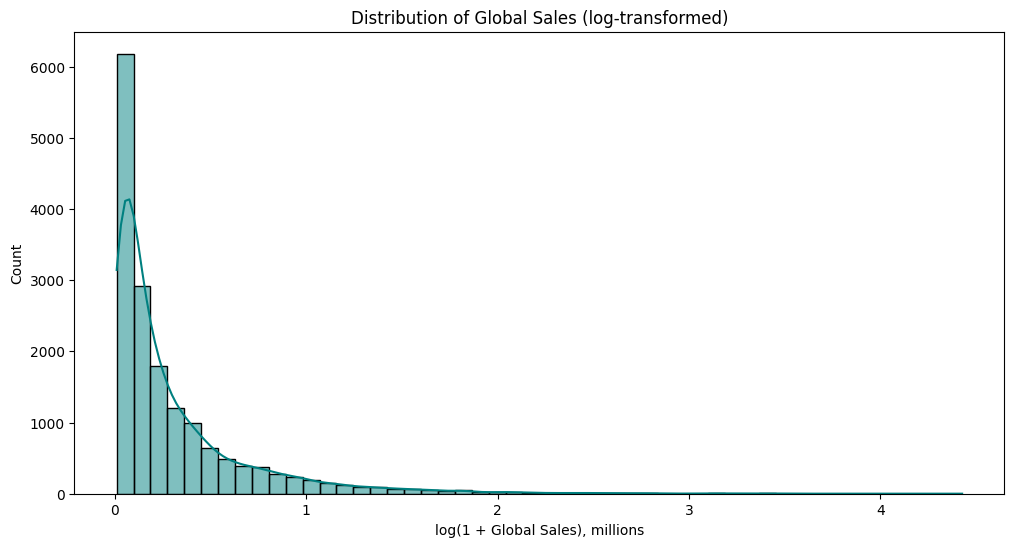

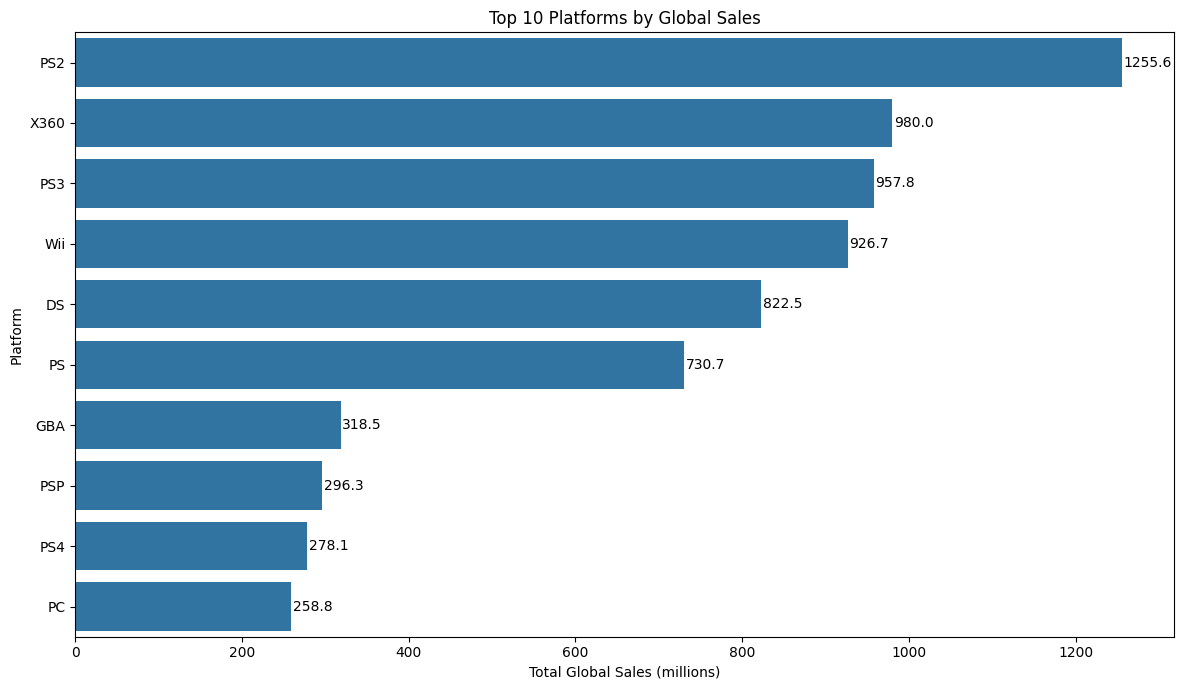

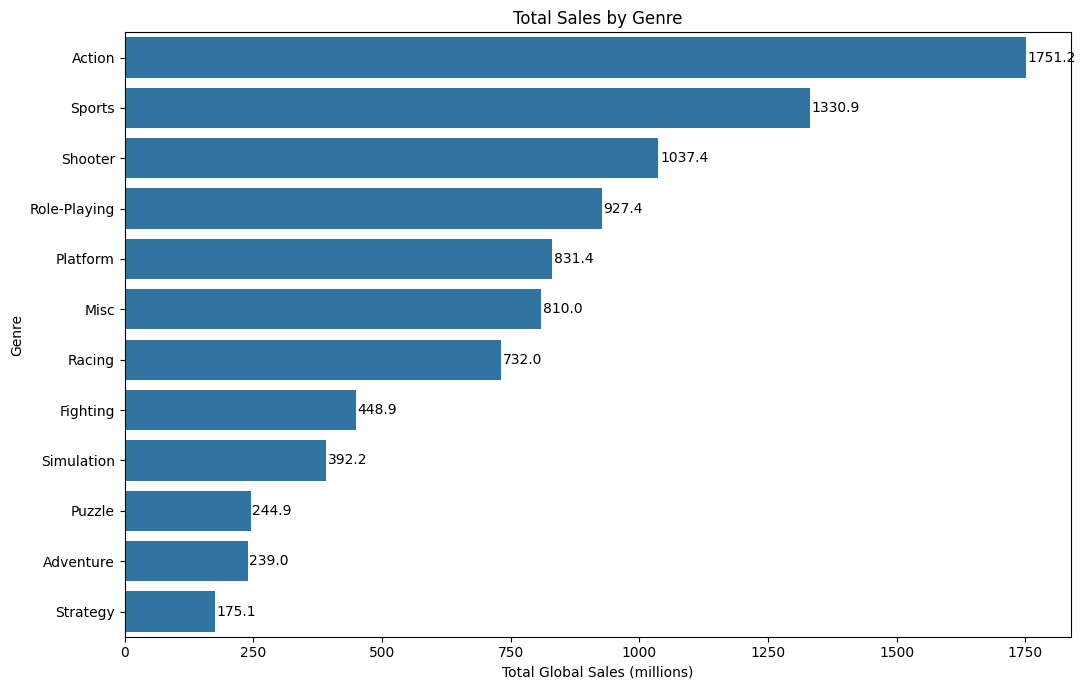

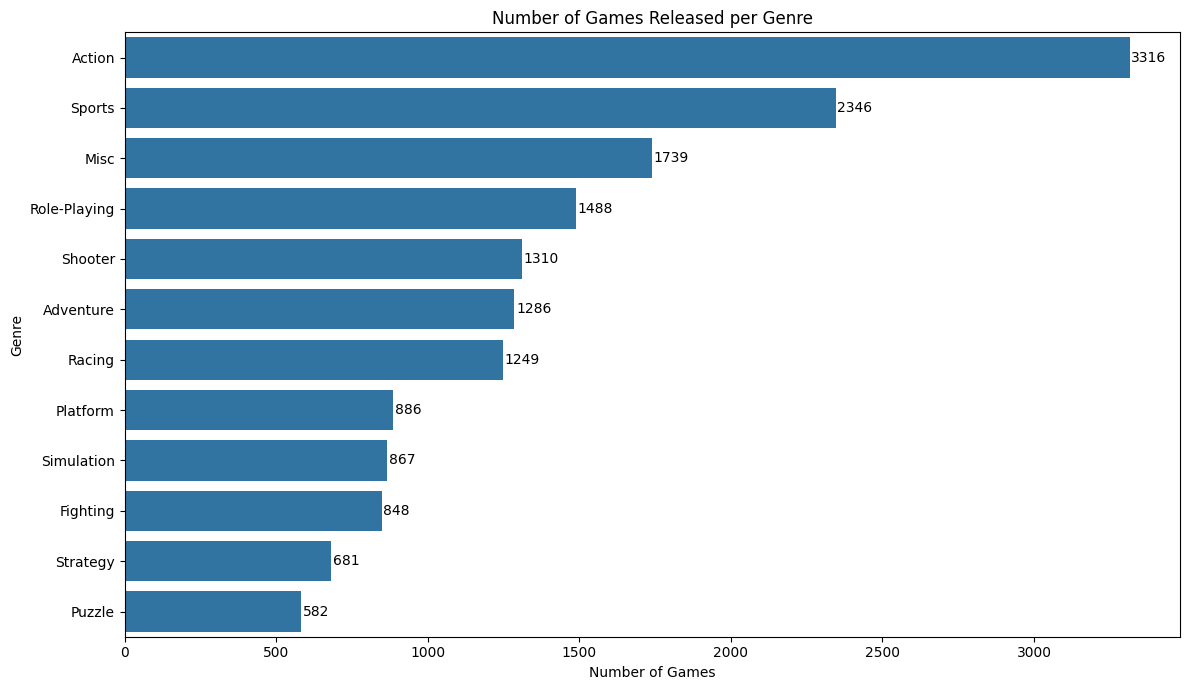

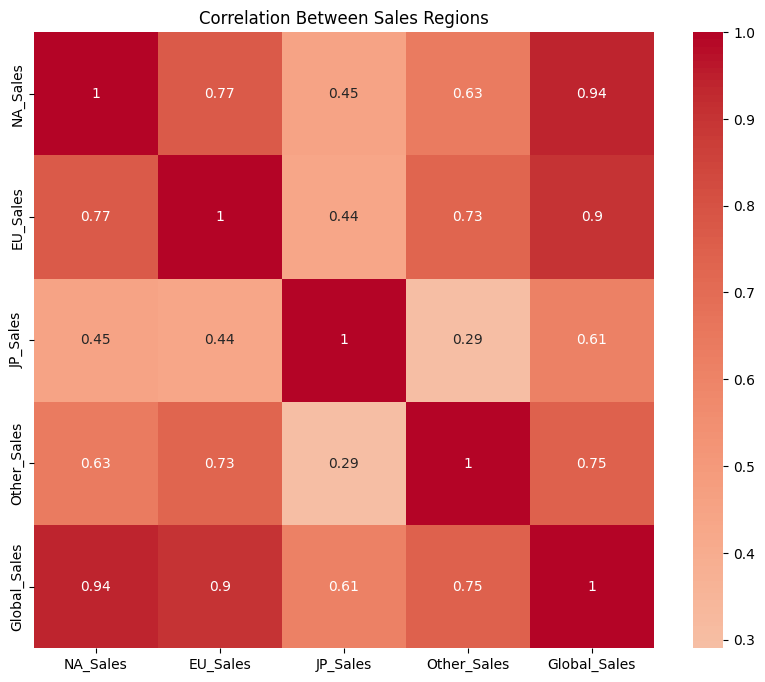

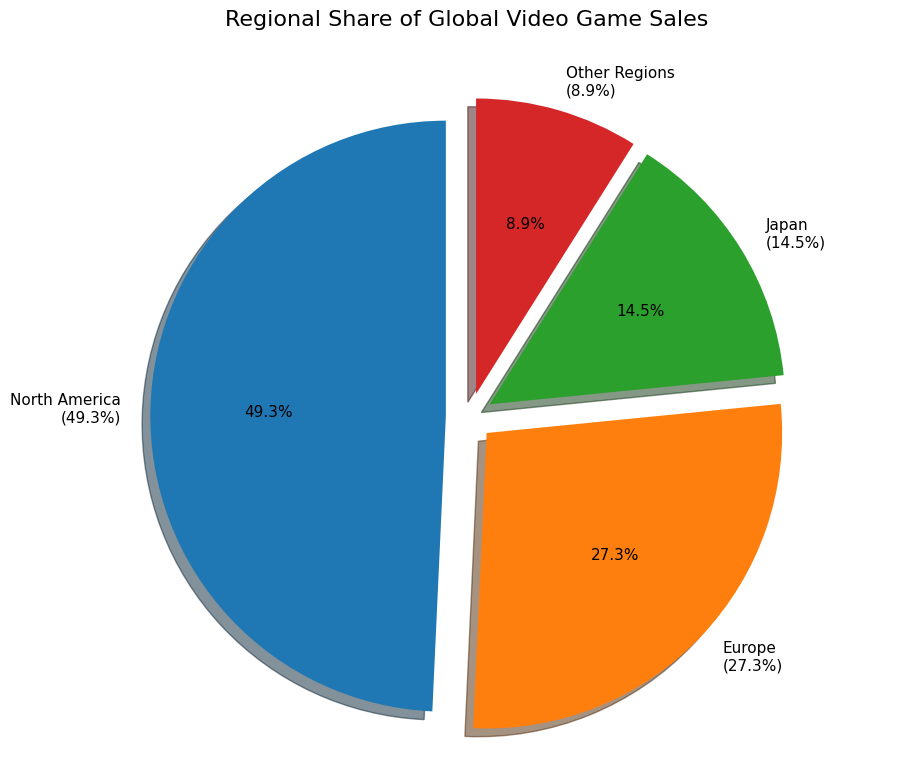

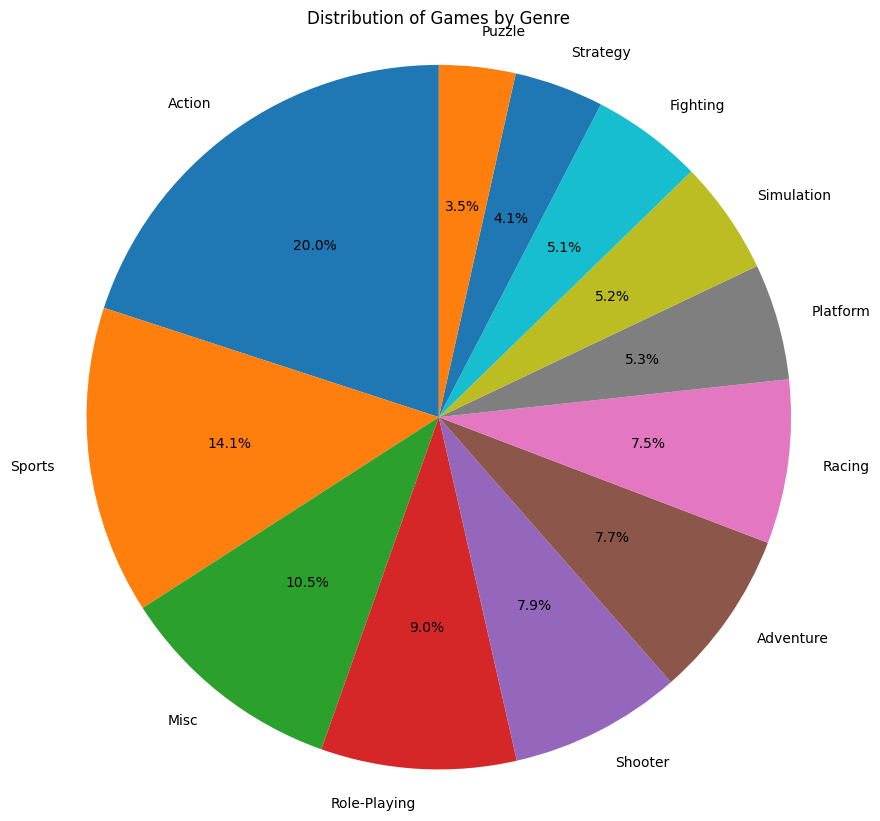

In [75]:
# 4. EXPLORATORY DATA ANALYSIS (EDA)

# 4.1 Sales Distribution (log-transformed due to strong right skew)
# Raw Global_Sales is heavily skewed: most games sell under 1M copies,
# while a handful of blockbusters (e.g. Wii Sports, GTA V) sell 20-80M+.
# A log1p transform makes the distribution readable instead of one tall
# bar near zero with a long flat tail.
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(df['Global_Sales']), kde=True, bins=50, color='teal')
plt.title('Distribution of Global Sales (log-transformed)')
plt.xlabel('log(1 + Global Sales), millions')
plt.ylabel('Count')
plt.show()

# 4.2 Top Platforms
plt.figure(figsize=(12, 7))
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
ax = sns.barplot(x=platform_sales.values, y=platform_sales.index)
plt.title('Top 10 Platforms by Global Sales')
plt.xlabel('Total Global Sales (millions)')
for i, v in enumerate(platform_sales.values):
    ax.text(v + 2, i, f'{v:.1f}', va='center')

plt.tight_layout()
plt.show()

# 4.3 Top Genres
plt.figure(figsize=(11, 7))
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
ax = sns.barplot(x=genre_sales.values, y=genre_sales.index)
plt.title('Total Sales by Genre')
plt.xlabel('Total Global Sales (millions)')
for i, v in enumerate(genre_sales.values):
    ax.text(v + 3, i, f'{v:.1f}', va='center')

plt.tight_layout()
plt.show()

# 4.4 Number of Games per Genre
plt.figure(figsize=(12, 7))
genre_count = df['Genre'].value_counts().sort_values(ascending=False)
ax = sns.barplot(x=genre_count.values, y=genre_count.index)
plt.title('Number of Games Released per Genre')
plt.xlabel('Number of Games')
plt.ylabel('Genre')
for i, v in enumerate(genre_count.values):
    ax.text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.show()

# 4.5 Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[sales_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Sales Regions')
plt.show()

# 4.6 Interactive Plotly (Sales over Years)
yearly = df_time.groupby('Year')['Global_Sales'].sum().reset_index()
fig = px.line(yearly, x='Year', y='Global_Sales', title='Global Video Game Sales Trend Over Years')
fig.show()

# 4.7 Regional Sales Share (Pie Chart)
regional_sales = {
    'North America': df['NA_Sales'].sum(),
    'Europe': df['EU_Sales'].sum(),
    'Japan': df['JP_Sales'].sum(),
    'Other Regions': df['Other_Sales'].sum()
}

total = sum(regional_sales.values())
percentages = [f'{v/total*100:.1f}%' for v in regional_sales.values()]

plt.figure(figsize=(11, 9))
plt.pie(regional_sales.values(),
        labels=[f'{k}\n({p})' for k, p in zip(regional_sales.keys(), percentages)],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.08, 0.08, 0.08, 0.08],
        shadow=True,
        textprops={'fontsize': 11})
plt.title('Regional Share of Global Video Game Sales', fontsize=16, pad=30)
plt.axis('equal')
plt.show()

# 4.8 Games per Genre (Pie Chart)
plt.figure(figsize=(10, 10))
plt.pie(genre_count.values, labels=genre_count.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Games by Genre')
plt.axis('equal')
plt.show()

In [76]:
# 5. FEATURE ENGINEERING (for Classification Task)

# We are framing the problem as binary classification:
# "Hit" = Global_Sales > median (successful game)
# "Not Hit" = otherwise
# This avoids the difficulty of exact sales prediction and data leakage.

median_sales = df['Global_Sales'].median()
df['Hit'] = (df['Global_Sales'] > median_sales).astype(int)

print(f"Median Global Sales used as threshold: {median_sales:.3f}")
print("\nTarget distribution (Hit vs Not Hit):")
print(df['Hit'].value_counts(normalize=True))

# Group rare publishers to reduce dimensionality
top_publishers = df['Publisher'].value_counts().head(20).index
df['Publisher_grouped'] = df['Publisher'].apply(lambda x: x if x in top_publishers else 'Other')

# One-hot encoding of categorical features
# We deliberately exclude sales columns (NA_Sales, EU_Sales, etc.) to prevent data leakage
categorical_features = ['Platform', 'Genre', 'Publisher_grouped']
X = pd.get_dummies(df[categorical_features + ['Year']],
                   columns=categorical_features,
                   drop_first=True)

y_clf = df['Hit']

# Train-test split with stratification to keep class balance
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled = scaler.transform(X_test_clf)

print("Features prepared for classification.")
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features after one-hot encoding: {X.shape[1]}")

Median Global Sales used as threshold: 0.170

Target distribution (Hit vs Not Hit):
Hit
0    0.505603
1    0.494397
Name: proportion, dtype: float64
Features prepared for classification.
Feature matrix shape: (16598, 62)
Number of features after one-hot encoding: 62


In [77]:
# 6. MACHINE LEARNING MODELS - CLASSIFICATION

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
}

clf_results = {}
clf_predictions = {}
clf_probabilities = {}

for name, model in clf_models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train_clf)
        pred = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_clf, y_train_clf)
        pred = model.predict(X_test_clf)
        proba = model.predict_proba(X_test_clf)[:, 1]

    acc = accuracy_score(y_test_clf, pred)
    prec = precision_score(y_test_clf, pred)
    rec = recall_score(y_test_clf, pred)
    f1 = f1_score(y_test_clf, pred)
    auc = roc_auc_score(y_test_clf, proba)

    clf_results[name] = {'Accuracy': acc, 'Precision': prec,
                        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}
    clf_predictions[name] = pred
    clf_probabilities[name] = proba

    print(f"\n{name} Performance:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

# Model Comparison
clf_results_df = pd.DataFrame(clf_results).T
print("\nClassification Model Comparison:")
display(clf_results_df)


Logistic Regression Performance:
Accuracy : 0.7057
Precision: 0.7080
Recall   : 0.6886
F1-Score : 0.6982
ROC-AUC  : 0.7739

Random Forest Performance:
Accuracy : 0.6834
Precision: 0.6756
Recall   : 0.6917
F1-Score : 0.6835
ROC-AUC  : 0.7462

XGBoost Performance:
Accuracy : 0.7169
Precision: 0.7098
Recall   : 0.7227
F1-Score : 0.7162
ROC-AUC  : 0.7939

Classification Model Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.705723,0.708020,0.688605,0.698177,0.773913
Random Forest,0.683434,0.675595,0.691651,0.683529,0.746158
XGBoost,0.716867,0.709755,0.722730,0.716184,0.793941


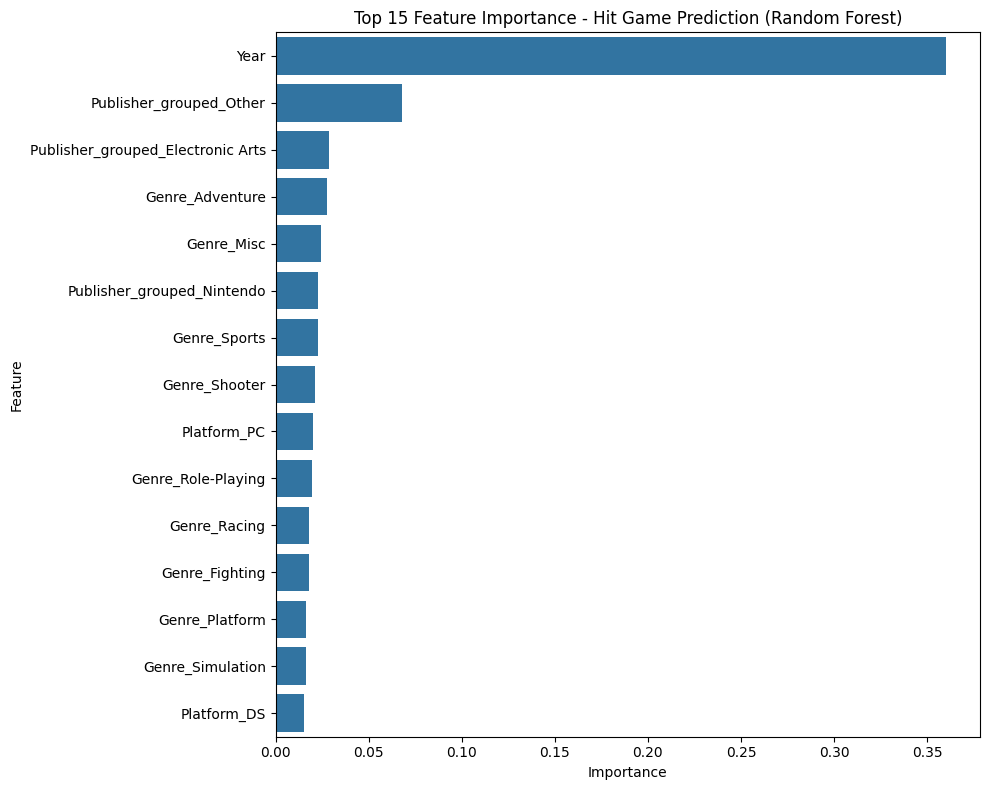

Top 15 Most Important Features:


,Feature,Importance
0,Year,0.360343
52,Publisher_grouped_Other,0.067718
47,Publisher_grouped_Electronic Arts,0.028940
31,Genre_Adventure,0.027536
33,Genre_Misc,0.024264
51,Publisher_grouped_Nintendo,0.022630
40,Genre_Sports,0.022567
38,Genre_Shooter,0.021231
13,Platform_PC,0.020310
37,Genre_Role-Playing,0.019382


In [78]:
# 7. FEATURE IMPORTANCE (Random Forest)

rf_clf = clf_models["Random Forest"]
importances = rf_clf.feature_importances_

feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_importance)
plt.title('Top 15 Feature Importance - Hit Game Prediction (Random Forest)')
plt.tight_layout()
plt.show()

print("Top 15 Most Important Features:")
display(feat_importance)

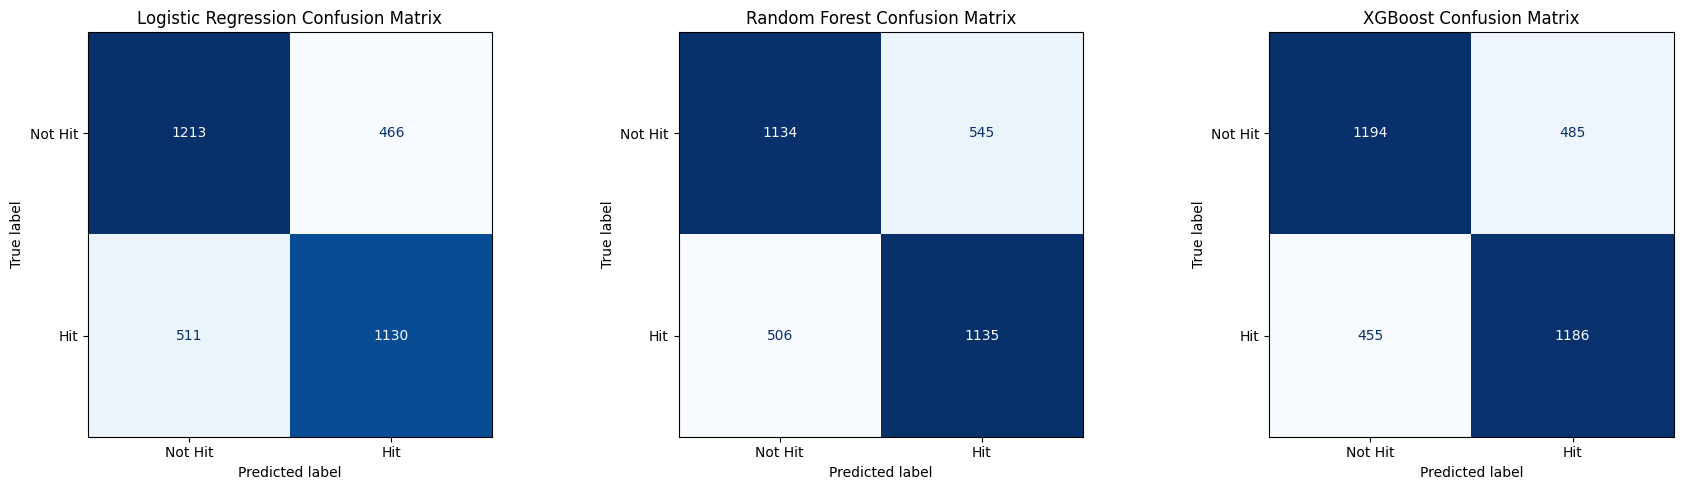

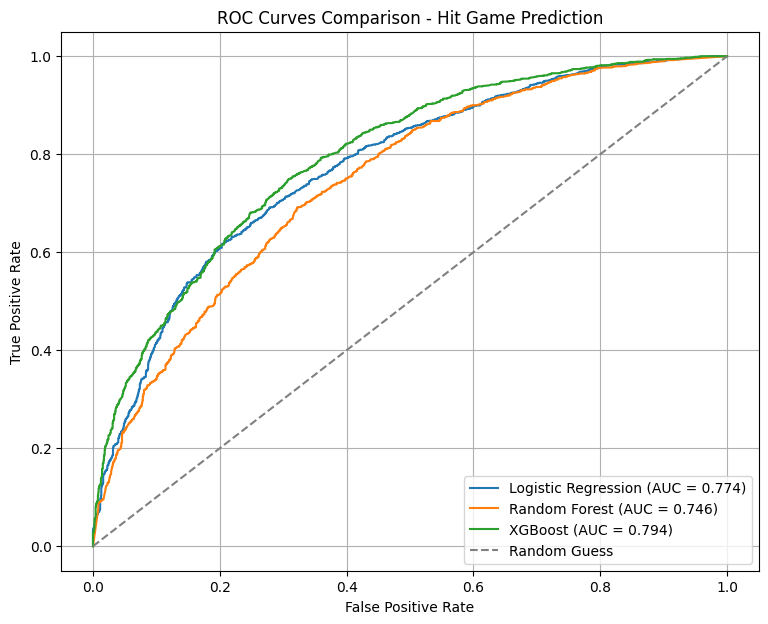

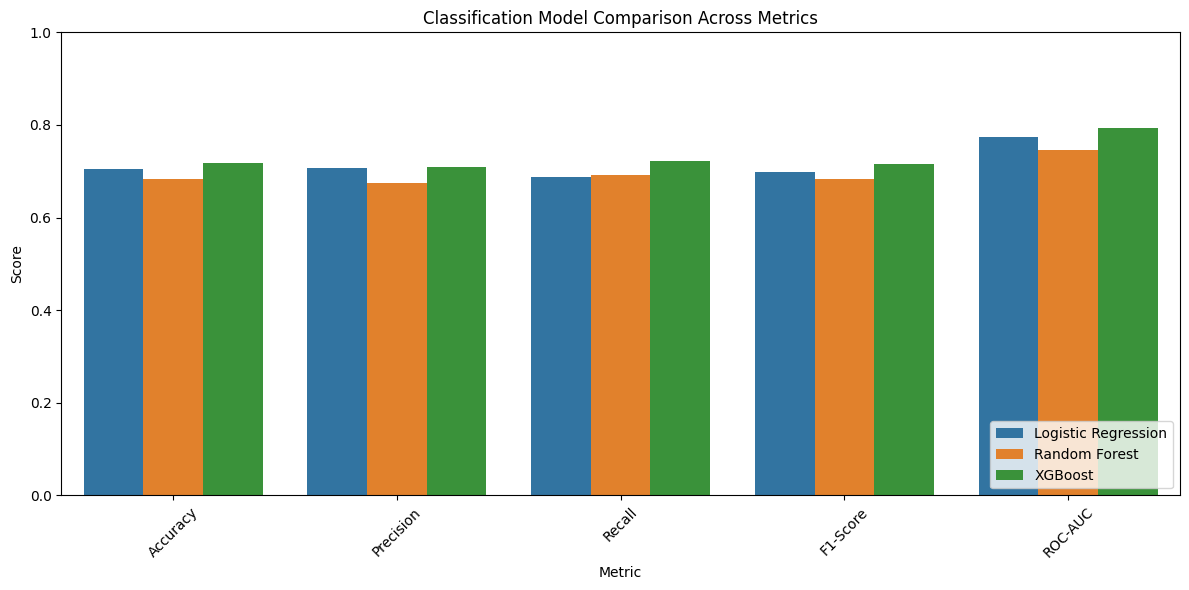

In [79]:
# 8. MODEL EVALUATION VISUALIZATIONS

# 8.1 Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred) in zip(axes, clf_predictions.items()):
    cm = confusion_matrix(y_test_clf, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Hit', 'Hit'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.show()

# 8.2 ROC Curves Comparison
plt.figure(figsize=(9, 7))
for name, proba in clf_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test_clf, proba)
    auc_score = roc_auc_score(y_test_clf, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison - Hit Game Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 8.3 Metrics Comparison Bar Chart
clf_results_melted = clf_results_df.reset_index().melt(id_vars='index',
                                                       var_name='Metric',
                                                       value_name='Score')
clf_results_melted = clf_results_melted.rename(columns={'index': 'Model'})

plt.figure(figsize=(12, 6))
sns.barplot(data=clf_results_melted, x='Metric', y='Score', hue='Model')
plt.title('Classification Model Comparison Across Metrics')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top 5 Games in NA:


,Name,Platform,Year,NA_Sales
0,Wii Sports,Wii,2006,41.49
1,Super Mario Bros.,NES,1985,29.08
9,Duck Hunt,NES,1984,26.93
5,Tetris,GB,1989,23.20
2,Mario Kart Wii,Wii,2008,15.85



Top 5 Games in EU:


,Name,Platform,Year,EU_Sales
0,Wii Sports,Wii,2006,29.02
2,Mario Kart Wii,Wii,2008,12.88
3,Wii Sports Resort,Wii,2009,11.01
10,Nintendogs,DS,2005,11.00
16,Grand Theft Auto V,PS3,2013,9.27



Top 5 Games in JP:


,Name,Platform,Year,JP_Sales
4,Pokemon Red/Pokemon Blue,GB,1996,10.22
12,Pokemon Gold/Pokemon Silver,GB,1999,7.20
1,Super Mario Bros.,NES,1985,6.81
6,New Super Mario Bros.,DS,2006,6.50
20,Pokemon Diamond/Pokemon Pearl,DS,2006,6.04


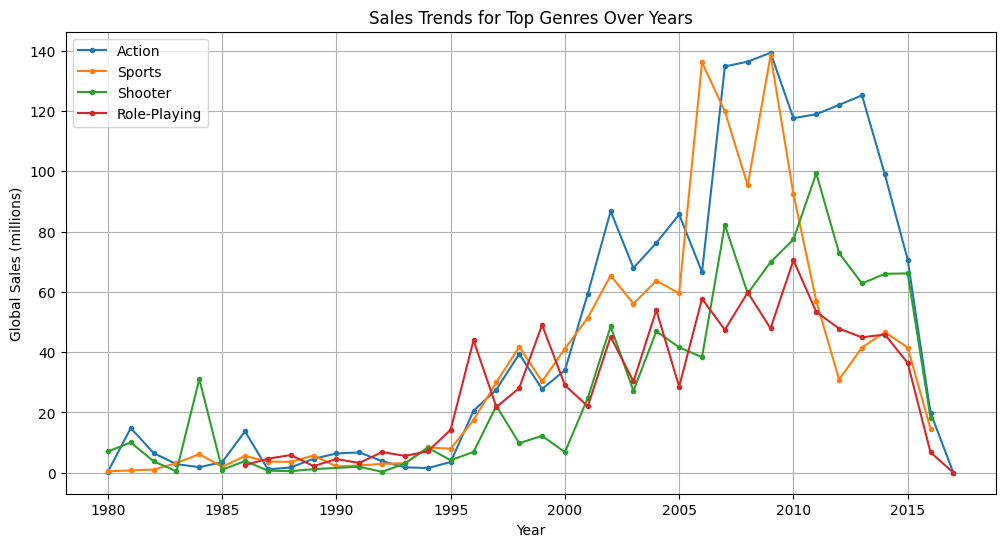

In [80]:
# 9. ADDITIONAL INSIGHTS

# Top games per region
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales']
for region in regions:
    top = df.nlargest(5, region)[['Name', 'Platform', 'Year', region]]
    print(f"\nTop 5 Games in {region.replace('_Sales', '')}:")
    display(top)

# Genre popularity over time (sample)
plt.figure(figsize=(12, 6))
top_genres = ['Action', 'Sports', 'Shooter', 'Role-Playing']
for genre in top_genres:
    genre_data = df[df['Genre'] == genre].groupby('Year')['Global_Sales'].sum()
    plt.plot(genre_data.index, genre_data.values, label=genre, marker='o', markersize=3)
plt.title('Sales Trends for Top Genres Over Years')
plt.xlabel('Year')
plt.ylabel('Global Sales (millions)')
plt.legend()
plt.grid(True)
plt.show()